In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.api import OLS, add_constant

pairs = [
    ("AAPL", "MSFT"),
    ("NVDA", "AMD"),
    ("KO", "PEP"),
    ("XOM", "CVX"),
    ("JPM", "BAC")
]

price_data = pd.read_csv("../data/prices.csv", index_col = 0, parse_dates = True).dropna()

# Split data 
split_idx = int(len(price_data) * 0.5) 
split_date = price_data.index[split_idx]

train = price_data.loc[:split_date]
test = price_data.loc[split_date:]

In [9]:
# Function to backtest the returns
def pair_returns(price_data, t1, t2, window, entry_z, cost = 0.0005):

    # Using Log prices 
    x = np.log(price_data[t1])
    y = np.log(price_data[t2])

    # Estimate beta
    X = add_constant(x)
    model = OLS(y,X).fit()
    beta = model.params.iloc[1]

    # Spread
    spread = y - beta* x

    # Z-Score
    mean = spread.rolling(window).mean()
    std = spread.rolling(window).std()
    zscore = (spread - mean)/ std

    # Compute trading signals
    position = pd.Series(0, index = spread.index)
    position.loc[zscore > entry_z] = -1
    position.loc[zscore < entry_z] = 1
    position = position.ffill().fillna(0)

    spread_ret = spread.diff()
    strategy_ret = position.shift(1) * spread_ret

    # Transaction cost
    trades = position.diff().abs()
    strategy_ret = strategy_ret - trades*cost


    return strategy_ret.fillna(0)

In [30]:
# Volatility-Scaled Portifolio Construction
vol_window = 20 # volatility lookback window = 20 days, ~ 1 trading month
target_vol = 0.10 # annualised volatility target
daily_target = target_vol / np.sqrt(252) # converts annual volatility to daily volatility

scaled_returns = pd.DataFrame(index = test.index)

for (t1,t2) in pairs:

    # Best window and Z-score
    best_sharpe = -np.inf
    for window in [10,20,30]:
        for z in [1.5, 2, 2.5]:
            r = pair_returns(train, t1, t2, window, z)
            sharpe = r.mean() / r.std()
            if sharpe > best_sharpe:
                best_sharpe = sharpe
                best_window, best_z = window, z

    r = pair_returns(test, t1, t2, int(best_window), best_z) # generate raw pair returns

    # Rolling volatility estimate
    vol = r.rolling(vol_window).std().shift(1)
    vol = vol.replace(0, np.nan) # stop division by 0

    # Scaling factor
    scale = daily_target / vol

    # Apply scaling
    scaled_r = r * scale
    scaled_returns[f"{t1}_{t2}"] = scaled_r # add scaling returns as a column

    # Equal weight portifolio after scaling
    scaled_returns["Portifolio"] = scaled_returns.mean(axis = 1)
    scaled_returns = scaled_returns.dropna()

scaled_returns.head()

,AAPL_MSFT,Portifolio,NVDA_AMD,KO_PEP,XOM_CVX,JPM_BAC
Date,,,,,,
2024-09-09,0.553488,-0.036703,-0.743693,0.005021,-0.117084,0.145709
2024-09-10,0.062500,0.111407,0.032992,-0.002194,0.147855,0.371760
2024-09-11,0.020727,-0.006522,-0.060248,-0.010638,0.010957,0.010733
2024-09-12,0.008133,0.001540,-0.009355,0.007004,0.000102,0.001773
2024-09-13,-0.008616,0.005042,0.005808,0.001084,0.024506,0.003193


In [31]:
# Perfomance Evaluation
def performance_stats(returns):

    sharpe = returns.mean() / returns.std() * np.sqrt(252)
    cagr = (1+ returns).prod() ** (252/len(returns)) - 1

    equity = (1 + returns).cumprod()
    peak = equity.cummax()
    drawdown = (equity - peak) / peak
    max_dd = drawdown.min()

    return sharpe, cagr, max_dd

sharpe, cagr, max_dd = performance_stats(scaled_returns["Portifolio"])

print("Vol-Targeted Sharpe:", sharpe)
print("Vol-Targeted CAGR:", cagr)
print("Vol-Targeted Max Drawdown:", max_dd)

Vol-Targeted Sharpe: 0.5755082708686483
Vol-Targeted CAGR: 0.0600413095010679
Vol-Targeted Max Drawdown: -0.05432625258799566


### Interpretation
Note that our Sharpe has improved (in general not a high sharpe) from day 19's -0.37055, suggesting that we had an issue of poor risk allocation, and since is isnt negative anymore, the signal isn't as weak as before.

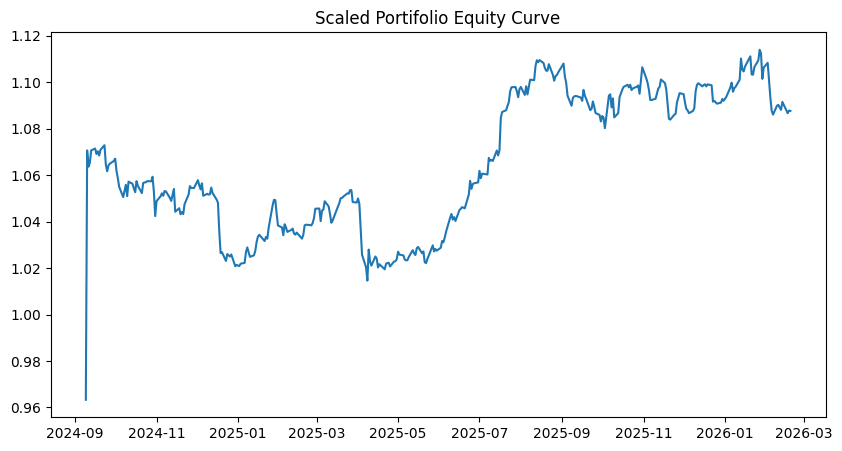

In [33]:
# Plot equity curve
equity = (1 + scaled_returns["Portifolio"]).cumprod()

plt.figure(figsize=(10,5))
plt.plot(equity)
plt.title("Scaled Portifolio Equity Curve")
plt.show()